### PROYECTO FINAL 4GEEKS

### PUNTO 1. DEFINICION DEL PROBLEMA

En la industria el control de calidad es una de las areas mas importantes y requiere de una alta atencion al detalle. Por ende, se va a realizar un proyecto con el objetivo principal de desarollar un modelo ML para predecir la calidad de los vinos a partir de una base de datos de sus propiedades fisicoquimicas, con el fin de reducir tiempos (time to market) y costos de analisis. A su vez, poder tomar decisiones y acciones de mejora en los procesos de calidad industrial

### - Variable objetiva (Target): 

- Calidad 'quality'

### - Variables predictores: 

 - Fixed acidity
 - Volatile acidity
 - Citric acid
 - Residual Sugar
 - Chlorides
 - Free sulfur dioxide
 - Total sulfur dioxide
 - Density
 - pH
 - Sulphates
 - Alcohol

Importación de librerias

In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [236]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [237]:
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

plt.style.use('ggplot')

### PUNTO 2. OBTENCION Y CARGA DE CONJUNTO DE DATOS 

Importación de los dataset, son tomados de UCI Machine Learning Repository

In [238]:
white = pd.read_csv('winequality-white.csv', sep=';')
red = pd.read_csv('winequality-red.csv', sep=';')

Obtuve dos dataset. Uno corresponde a datos de vino rojo y otro de vino blanco, los cuales los uniré, para ello, agregare una columna y después concatenar los dos datasets

In [239]:
red['wine_type'] = 'Red'
white['wine_type'] = 'White'

In [240]:
wine_data = pd.concat([red, white], ignore_index=True)

Revisando el tipo de info, varibales y datos disponibles

In [241]:
wine_data.shape

(6497, 13)

In [242]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red


In [243]:
wine_data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

In [244]:
wine_data.duplicated().sum()

np.int64(1177)

In [245]:
columnas_duplicadas = wine_data[wine_data.duplicated()]

columnas_duplicadas['wine_type'].value_counts()

wine_type
White    937
Red      240
Name: count, dtype: int64

Aqui me doy cuenta que los vinos blancos tienen mas datos repetidos que el dataset del vino rojo

In [246]:
columnas_duplicadas['quality'].value_counts().sort_index()

quality
4     10
5    386
6    513
7    223
8     45
Name: count, dtype: int64

Se puede determinar que los datos repetidos corresponden a la columna de calidad, y es porque hay un rango de 0-9, el número 5 y 6 son los más repetidos. Por tal razon, no voy a cambiar ni a eliminar los datos duplicados 

### PUNTO 4. REALIZAR UN ANALISIS DESCRIPTIVO

In [247]:
wine_data.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


A partir de la estadistica descriptiva observo que:
- El promedio del pH de los vinos es de 3.2, es decir que la gran mayoria de vinos tienden a hacer acidos, propiedad caracteristica de los vinos.

- La calidad de los vinos tienen un promedio de 5.8, se puede decir que, no son vinos premium sino, vinos normales a nivel comercial (promedios).

- El % de alcohol tiene un promedio de 10,4%

- Existe un dato atipico con el azucar residual, se observa que el 75% es 8.1, pero existe un max de 65.8

Revisando el outliter del azucar residual

In [248]:
max_valor = wine_data['residual sugar'].max()
fila_max = wine_data[wine_data['residual sugar'] == max_valor]

print(fila_max)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
4380            7.8             0.965          0.6            65.8      0.074   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
4380                  8.0                 160.0  1.03898  3.39       0.69   

      alcohol  quality wine_type  
4380     11.7        6     White  


Comparando las demas variables, se obtiene una densidad alta, o sea tiene sentido que el residuo de azucar sea alto, el acido citrico tambien, por ende, no es un outlier negativo, tiene coherencia con las demas variables 

In [249]:
#residual_sorted = wine_data.sort_values(by='residual sugar', ascending=False)
#print(residual_sorted.head(20))

Realizaré un análisis de correlaciones y distribución de datos para detectar hacia que lado estan los datos 

In [250]:
wine_numerico = wine_data.select_dtypes(include = 'number')             #Aqui estoy seleccionando solo las columnas numericas del dataset
corr_matrix = wine_numerico.corr()

In [251]:
corr_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.076743
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.265699
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.085532
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.036980
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.200666
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.055463
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.041385
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.305858
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.019506
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.038485


Para poder detectar mejor los outliers, grafico un heatmap y un hist

### Matriz de correlación

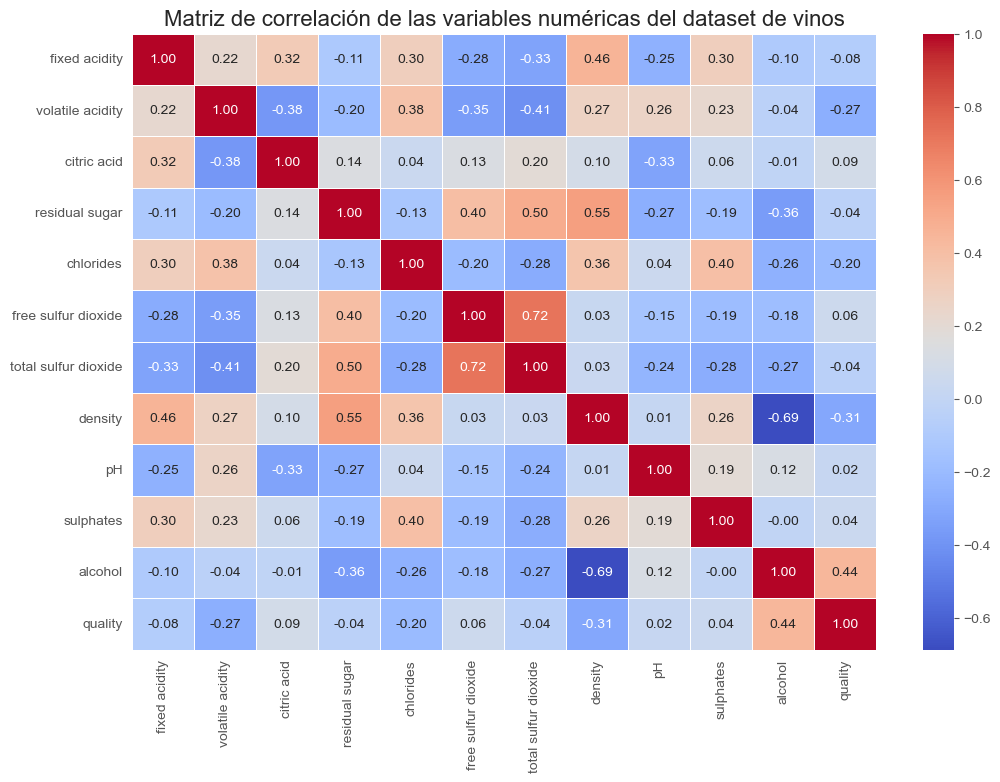

In [252]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,                         #Muestra los valores de correlacion en cada celda
    fmt=".2f",                          #Muestra dos decimales en los valores de correlacion
    cmap="coolwarm",                    #Esquema de colores, rojo para correlacion positiva y azul para correlacion negativa
    linewidths=0.5,                     #Separa las celdas con un borde de 0.5   
    cbar=True,
)

plt.title("Matriz de correlación de las variables numéricas del dataset de vinos", fontsize=16)

plt.show()

Que me indica las correlaciones:
- 1 tiene una correlacion positiva perfecta
- 0 no existe relacion lineal
- -1 tiene una correlacion negativa perfecta

Que se concluye a partir de la correlacion:
- Calidad: Esta tiene una correlacion 0.44, es decir, positiva moderada, cuando el contenido de alcohol aumenta, la calidad sensorial tiende a aumentar(recibe mejor puntuación sensorial)

- Densidad: Corr = -0.31, es decir, se tiene una correlación negativa moderada, es decir, a mayor densidad, menor calidad del vino. Esto esta asociado que cuando la densidad es alta existe un mayor contenido de azucar residual y menor grado de fermantacion (baja calidad del vino)

- Acidez volatil: Corr = -0.21, La acidez volatil está relacionada con la presencia del ácido acético, cuando está aumenta, genera aromas avinagrados, por tal razón no se tiene una buena puntuacion (calidad)

### Distribucion de variable objetivo 

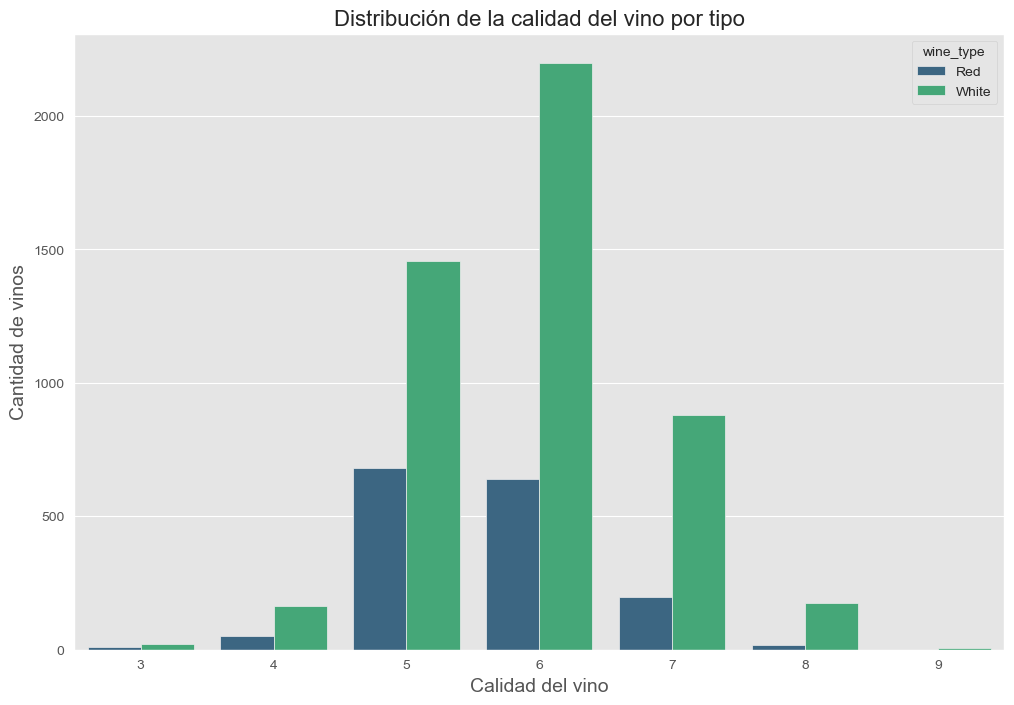

In [253]:
plt.figure(figsize=(12, 8))

sns.countplot(data=wine_data, x='quality', hue='wine_type', palette='viridis')

plt.title("Distribución de la calidad del vino por tipo", fontsize=16)
plt.xlabel("Calidad del vino", fontsize=14)
plt.ylabel("Cantidad de vinos", fontsize=14)

plt.show()

Se puede determinar que los vinos blancos tienen a tener una mejor puntuacion de caliad respecto a los vinos tintos 

### Distribucion de todas las variables 

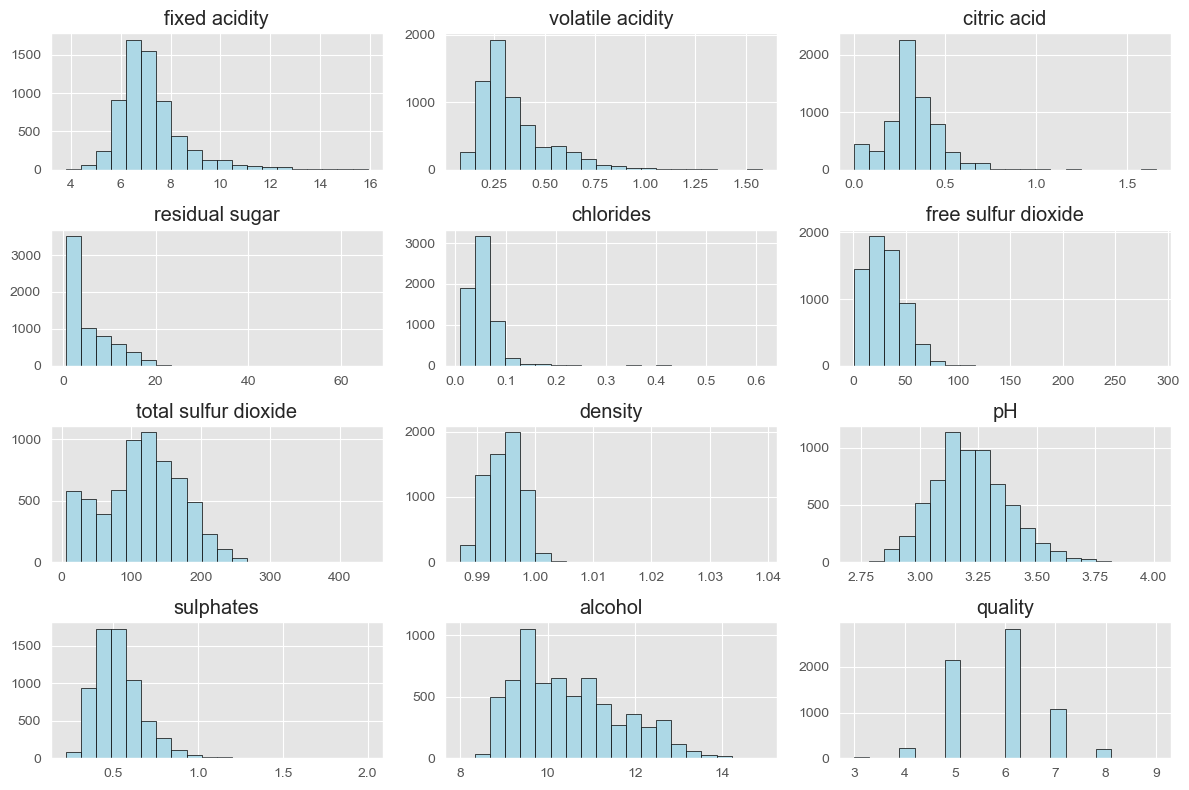

In [254]:
wine_data.hist(figsize=(12, 8), bins=20, color='lightblue', edgecolor='black')

plt.tight_layout()

plt.show()

Se puede determinar que los datos de acidez volatil, acido citrico, azucar residua, sulfatos tienden a la izquierda, el pH tiene una distribucion normal de datos, y los datos de la calidad estan centrados en 5,6 y 7

### Relacion entre alcohol y calidad 

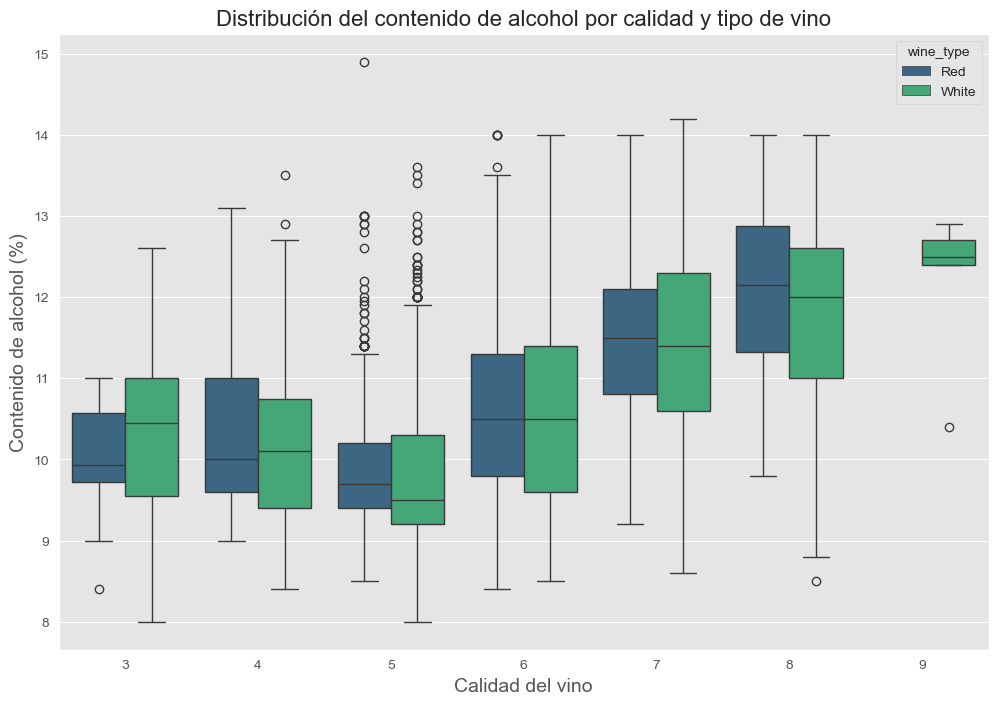

In [255]:
plt.figure(figsize=(12, 8))

sns.boxplot(
    data=wine_data,
    x='quality',
    y='alcohol',
    hue='wine_type',
    palette='viridis'
)

plt.title('Distribución del contenido de alcohol por calidad y tipo de vino', fontsize=16)
plt.xlabel('Calidad del vino', fontsize=14)
plt.ylabel('Contenido de alcohol (%)', fontsize=14)

plt.show()

A partir del boxplot, se puede observar :
- A medida que va aumentando el % de alcohol, tambien aumenta la calidad del vino.
- No hay vinos rojos clasificados en las calidad numero 9
- Existen varios outliers, hay unos vinos con calidad de 5 pero con un porcentaje de alcohol de 15%, es decir, no siempre el porcentaje de alcohol puede definir la calidad del vino. 
- Existe un vino con calidad de 9 pero con un porcentaje de alcohol de 10, aplica para outlier


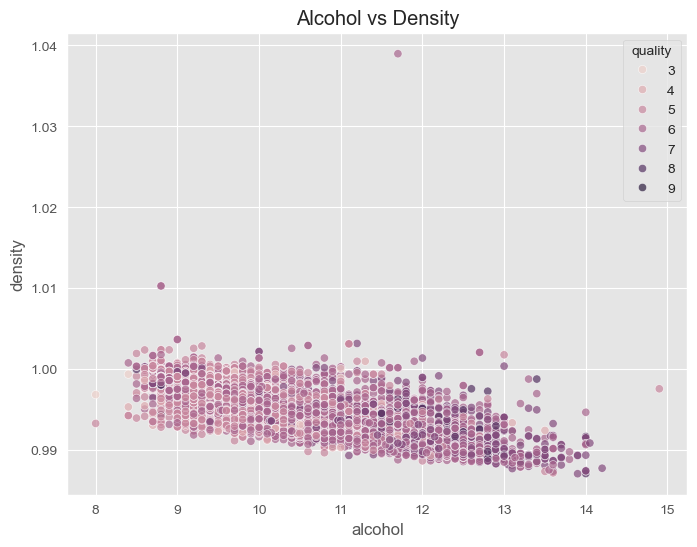

In [256]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=wine_data,
    x="alcohol",
    y="density",
    hue="quality",
    alpha=0.7
)

plt.title("Alcohol vs Density")

plt.show()

Se puede decir que existe una multicolinealidad entre estas dos variables. Los puntos mas oscuros son de calidad 8 y 9, la mayoria de estos se concentran en alcohol 12-14% y una densidad 0.998-0.992, en cambio, los de alcohol 9-11%, tienen una densidad de 0.994-1.00. 

Indica que mayor calidad, mayor % de alcohol tiene una menor densidad.

### Promedio de cada varible con cada nivel de calidad

In [257]:
promedio_calidad = wine_data.groupby("quality").mean(numeric_only=True)
promedio_calidad

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,7.853333,0.517000,0.281000,5.140000,0.077033,39.216667,122.033333,0.995744,3.257667,0.506333,10.215000
4,7.288889,0.457963,0.272315,4.153704,0.060056,20.636574,103.432870,0.994833,3.231620,0.505648,10.180093
5,7.326801,0.389614,0.307722,5.804116,0.064666,30.237371,120.839102,0.995849,3.212189,0.526403,9.837783
6,7.177257,0.313863,0.323583,5.549753,0.054157,31.165021,115.410790,0.994558,3.217726,0.532549,10.587553
7,7.128962,0.288800,0.334764,4.731696,0.045272,30.422150,108.498610,0.993126,3.228072,0.547025,11.386006
8,6.835233,0.291010,0.332539,5.382902,0.041124,34.533679,117.518135,0.992514,3.223212,0.512487,11.678756
9,7.420000,0.298000,0.386000,4.120000,0.027400,33.400000,116.000000,0.991460,3.308000,0.466000,12.180000


<Axes: xlabel='quality'>

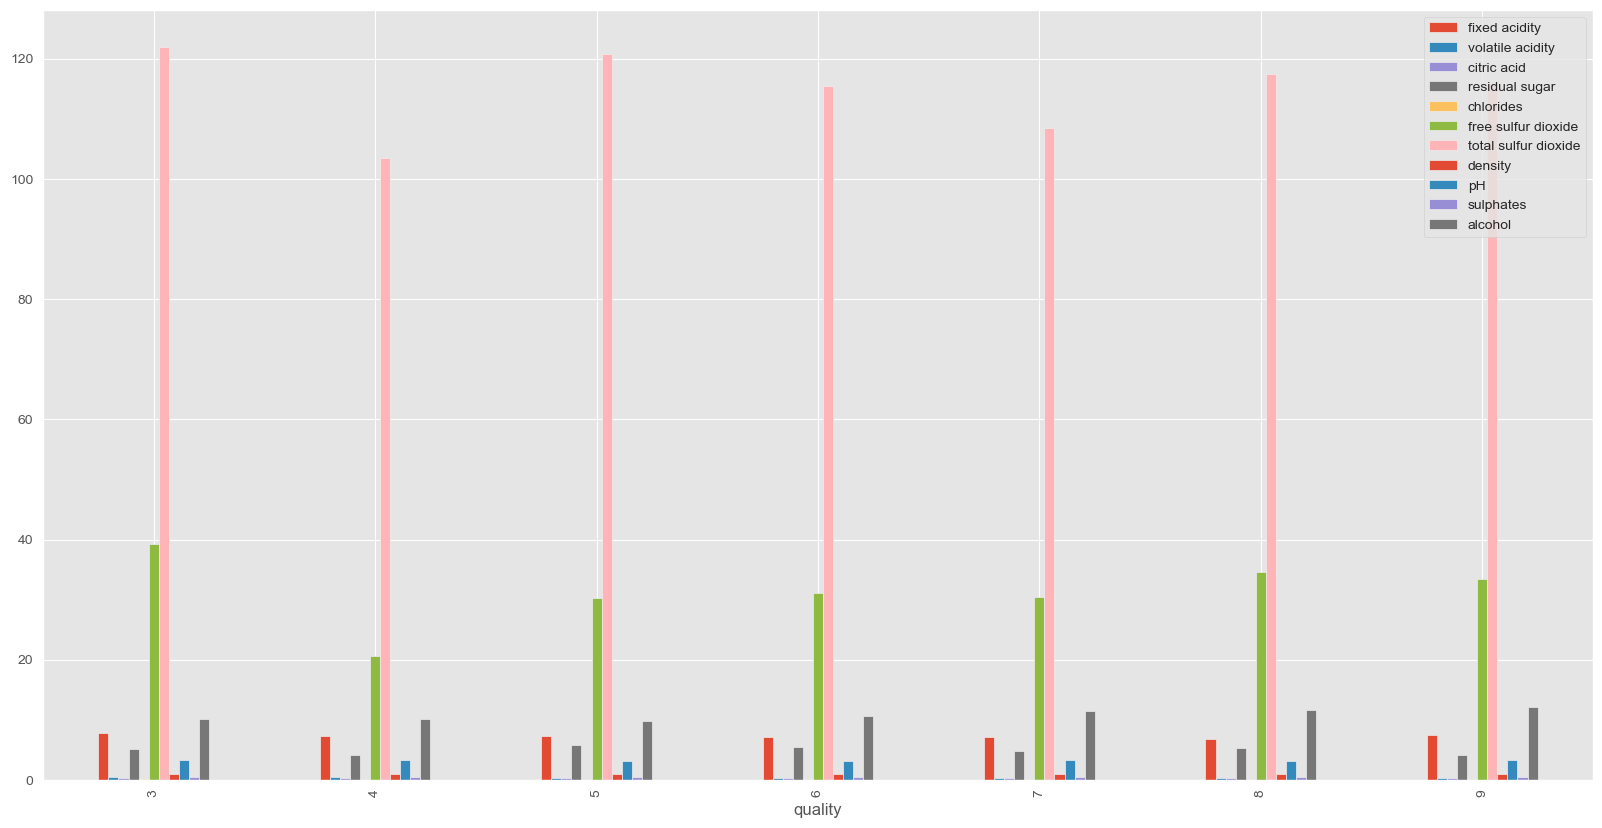

In [258]:
promedio_calidad.plot(kind="bar",figsize=(20,10))

Podemos decir que las varibles mas significativas son: el alcohol, la densidad se mantiene igual para todos los vinos,el total de dioxido de sulfuro, aunque esta se mantiene igual para todos los vinos, 

### CONCLUSIONES DEL EDA

1. No se obtuvo valores nulos
2. Tenemos valores duplicados, pero estos corresponden a la calisifacion de calidad 
3. La gran mayoria de vinos presentan una calidad de 5,6 y 7, no se tienen muchos vinos premium 
4. El contenido de alcohol tiene una relacion positiva y se puede decir que directamente proporcional con la calidad del vino.
5. La densidad tiene relacion negativa e inversa con la calidad del vino, esto se puede indicar que se tiene azucar residual y baja calidad de fermentacion y/o aromas avinagrados 
6. Ninguna variable tiene la certeza de explicar la calidad del vino
7. Existen valores outliers pero no son significativos y pueden ser justificables 

### Feature Engineering

1. Solo para el EDA y analisis, hare un bins de quality. 
Mi target es quality por ende, no usare la nueva variable en mi prediccion.

In [259]:
wine_data['quality_categoria'] = pd.cut(
wine_data['quality'], 
bins=[ 2.5, 5.5, 6.5, 9.5], 
labels=['Bajo', 'Medio', 'Alto']
)

In [260]:
(wine_data == 0).sum()

fixed acidity             0
volatile acidity          0
citric acid             151
residual sugar            0
chlorides                 0
free sulfur dioxide       0
total sulfur dioxide      0
density                   0
pH                        0
sulphates                 0
alcohol                   0
quality                   0
wine_type                 0
quality_categoria         0
dtype: int64

In [261]:
wine_data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'wine_type',
       'quality_categoria'],
      dtype='object')

2. Transformando los valores cercaos a cero a log, esto ayuda a beneficiarme de la distribucion normal

In [262]:
cols_log = [
    'citric acid',
    'residual sugar',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'chlorides'
]

wine_data[cols_log] = wine_data[cols_log].apply(np.log1p)

In [263]:
wine_numerico = wine_data.select_dtypes(include = 'number')             #Aqui estoy seleccionando solo las columnas numericas del dataset
corr_matrix = wine_numerico.corr()

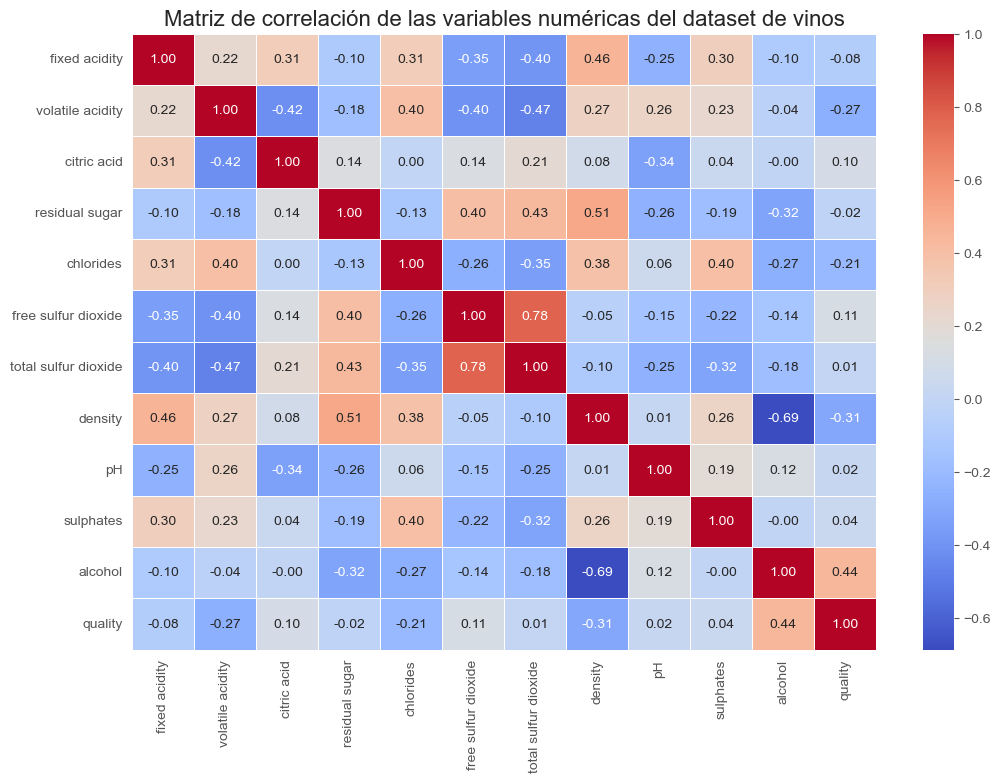

In [264]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,                         #Muestra los valores de correlacion en cada celda
    fmt=".2f",                          #Muestra dos decimales en los valores de correlacion
    cmap="coolwarm",                    #Esquema de colores, rojo para correlacion positiva y azul para correlacion negativa
    linewidths=0.5,                     #Separa las celdas con un borde de 0.5   
    cbar=True,
)

plt.title("Matriz de correlación de las variables numéricas del dataset de vinos", fontsize=16)

plt.show()

In [265]:
#wine_data['ratio_alcohol_densidad'] = wine_data['alcohol'] / wine_data['density']

#wine_data['ratio_azucar_alcohol'] = wine_data['alcohol'] / wine_data['residual sugar']


#wine_data['acidez_total'] = wine_data['fixed acidity'] + wine_data['volatile acidity'] + wine_data['citric acid']

### Procesamiento de Data

1. Convertire la variable categorica a valores numericos 

In [266]:
wine_data['wine_type'] = wine_data['wine_type'].map({
    'Red': 0,
    'White': 1
})

In [267]:
wine_data['wine_type'].value_counts()

wine_type
1    4898
0    1599
Name: count, dtype: int64

Defino la variable objetivo categorica a partir de quality:
- bajo: 3, 4, 5
- medio: 6
- alto: 7, 8, 9

In [268]:
wine_data['quality_categoria'] = pd.cut(
    wine_data['quality'],
    bins=[2.5, 5.5, 6.5, 9.5],
    labels=['Bajo', 'Medio', 'Alto']
)

print ('Distribucion de la calidad del vino por categoria:')
print(wine_data['quality_categoria'].value_counts())
print (wine_data['quality_categoria'].value_counts(normalize=True).round(3))

Distribucion de la calidad del vino por categoria:
quality_categoria
Medio    2836
Bajo     2384
Alto     1277
Name: count, dtype: int64
quality_categoria
Medio    0.437
Bajo     0.367
Alto     0.197
Name: proportion, dtype: float64


2. Separo las variables predictoras y objetivo

In [269]:
X = wine_data.drop(columns = ['quality', 'quality_categoria'])  #X es el conjunto de características (features) que se utilizarán para entrenar el modelo. Se eliminan las columnas 'quality' y 'quality_categoria' del DataFrame wine_data, ya que estas son las etiquetas que queremos predecir.

y = wine_data['quality_categoria']

In [270]:
print(X.shape)
print(y.shape)

(6497, 12)
(6497,)


3. Divido en entrenamiento y prueba, tomare un 80% para train y el 20% para test

Train-Test Split

In [271]:
from sklearn.model_selection import train_test_split

In [272]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    random_state=42,
    stratify = y                #Uso el stratify para asegurar que la distribución de clases en el conjunto de entrenamiento y prueba sea similar a la distribución original del conjunto de datos, poruqe 'quality' no esta balanceada
    )

In [273]:
print (f'\nTrain: {X_train.shape[0]} filas | Test: {y_train.shape[0]} filas')


Train: 5197 filas | Test: 5197 filas


4. Verifico la división

In [274]:
print (X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5197, 12) (1300, 12) (5197,) (1300,)


In [275]:
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())

quality_categoria
Bajo     0.366942
Medio    0.436598
Alto     0.196459
Name: proportion, dtype: float64
quality_categoria
Bajo     0.366923
Medio    0.436154
Alto     0.196923
Name: proportion, dtype: float64


5. Realizo escalado de los datos.

In [276]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### PUNTO 6. Desarrollo de modelo

### 1. REGRESION LOGISTICA

Creacion del modelo

In [277]:
from sklearn.linear_model import LogisticRegression

In [278]:
log_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

Entrenando el modelo

In [279]:
log_model.fit(X_train_scaled, y_train)          #X_train_scaled es el conjunto de entrenamiento escalado (son las propiedades fisicoquimicas de cada vino) y y_train es el conjunto de etiquetas de entrenamiento. El modelo se ajusta a estos datos para aprender los patrones y relaciones entre las características y las etiquetas.

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


Predicciones:

In [280]:
y_pred = log_model.predict(X_test_scaled)           #Es el arreglo de predicciones que hace el modelo logístico sobre el conjunto de prueba

In [281]:
print (y_pred[:10])

['Alto' 'Alto' 'Alto' 'Bajo' 'Bajo' 'Bajo' 'Bajo' 'Bajo' 'Bajo' 'Bajo']


Evaluación del modelo, comparando las predicciones con la realidad

In [282]:
from sklearn.metrics import  (ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report)

In [283]:
print("\n=== Métricas Regresión Logística ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-score (macro):  {f1_score(y_test, y_pred, average='macro'):.4f}")


=== Métricas Regresión Logística ===
Accuracy:  0.5438
Precision (macro): 0.5377
Recall (macro):    0.5869
F1-score (macro):  0.5378


- El accuracy me indica que acertó aproximadamente un 54% de las muestras

Matriz de confusión

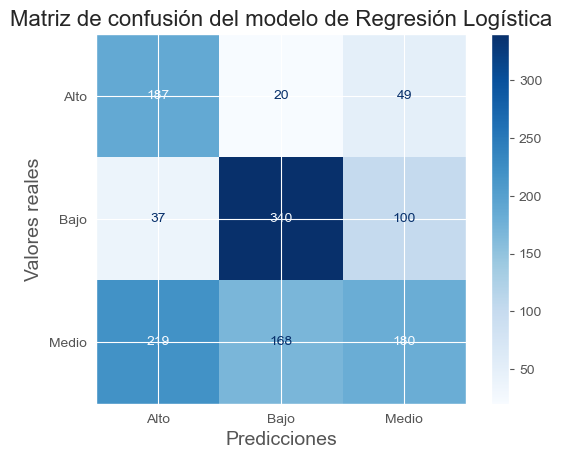

In [284]:

cm = confusion_matrix (y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = log_model.classes_
)

disp.plot(cmap='Blues')

plt.title('Matriz de confusión del modelo de Regresión Logística', fontsize=16)
plt.xlabel('Predicciones', fontsize=14)
plt.ylabel('Valores reales', fontsize=14)
#plt.savefig('matriz_confusion_logistica.png', dpi=300, bbox_inches='tight')
plt.show()


Fila 1: Acertó 187 vinos
- 187 vinos son positvos
- 20 vinos eran altos pero el modelo dijo bajos 
- 49 vinos eran altos pero el modelo dijo Medio 

Fila 2: Acertó 340 
- 340 clasificados correctamente 
- 37 fueron confundidos con vino de calidad alta
- 100 fueron confundidos con calidad media 

Fila 3:
- 180 fueron clasificados correctamente 
- 100 fueron confundidos con medio 
- 49 fueron confundidos con alto 

### CONCLUSION DEL MODELO DE REGRESION LOGISTICA 

El modelo de Regresión Logística no logró aprender a distinguir entre las categorias del vino. A pesar de haber ajustado el class_weight = 'balanced' para poder compensar el desbalance entre las clases, el modelo colapsó. 

Al trazar fronteras de decisión lineales entre clase, y tener datos en las variables predictoras tan similares entre si, no tuvo la capacidad de capturar esa relación. 

### 2. ARBOL DE DECISIONES / RANDOM FOREST

In [285]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [286]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    print(f"\n=== Métricas {nombre} ===")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro):    {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro):  {f1_score(y_test, y_pred, average='macro'):.4f}")
    
    cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=modelo.classes_
    )
    
    disp.plot(cmap='Blues')
    
    plt.title(f'Matriz de confusión del modelo de {nombre}', fontsize=16)
    plt.xlabel('Predicciones', fontsize=14)
    plt.ylabel('Valores reales', fontsize=14)
    plt.show()
    return y_pred

1. Modelo de Arbol de Decisión


=== Métricas Arbol de Decisión ===
Accuracy:  0.5892
Precision (macro): 0.5861
Recall (macro):    0.6222
F1-score (macro):  0.5917


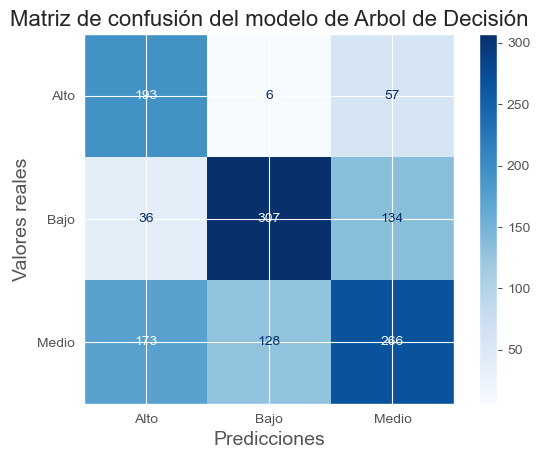

array(['Alto', 'Medio', 'Alto', ..., 'Medio', 'Bajo', 'Bajo'],
      shape=(1300,), dtype=object)

In [287]:
modelo_arbol = DecisionTreeClassifier (
    class_weight='balanced',
    max_depth=8,
    min_samples_split=5,        #Limito la profundidad del arbol para evitar el overfitting y mejorar la generalización del modelo. Esto significa que el árbol no se dividirá en nodos adicionales si el número de muestras en un nodo es menor que 5.
)

modelo_arbol.fit(X_train, y_train)
evaluar_modelo('Arbol de Decisión', modelo_arbol, X_test, y_test)

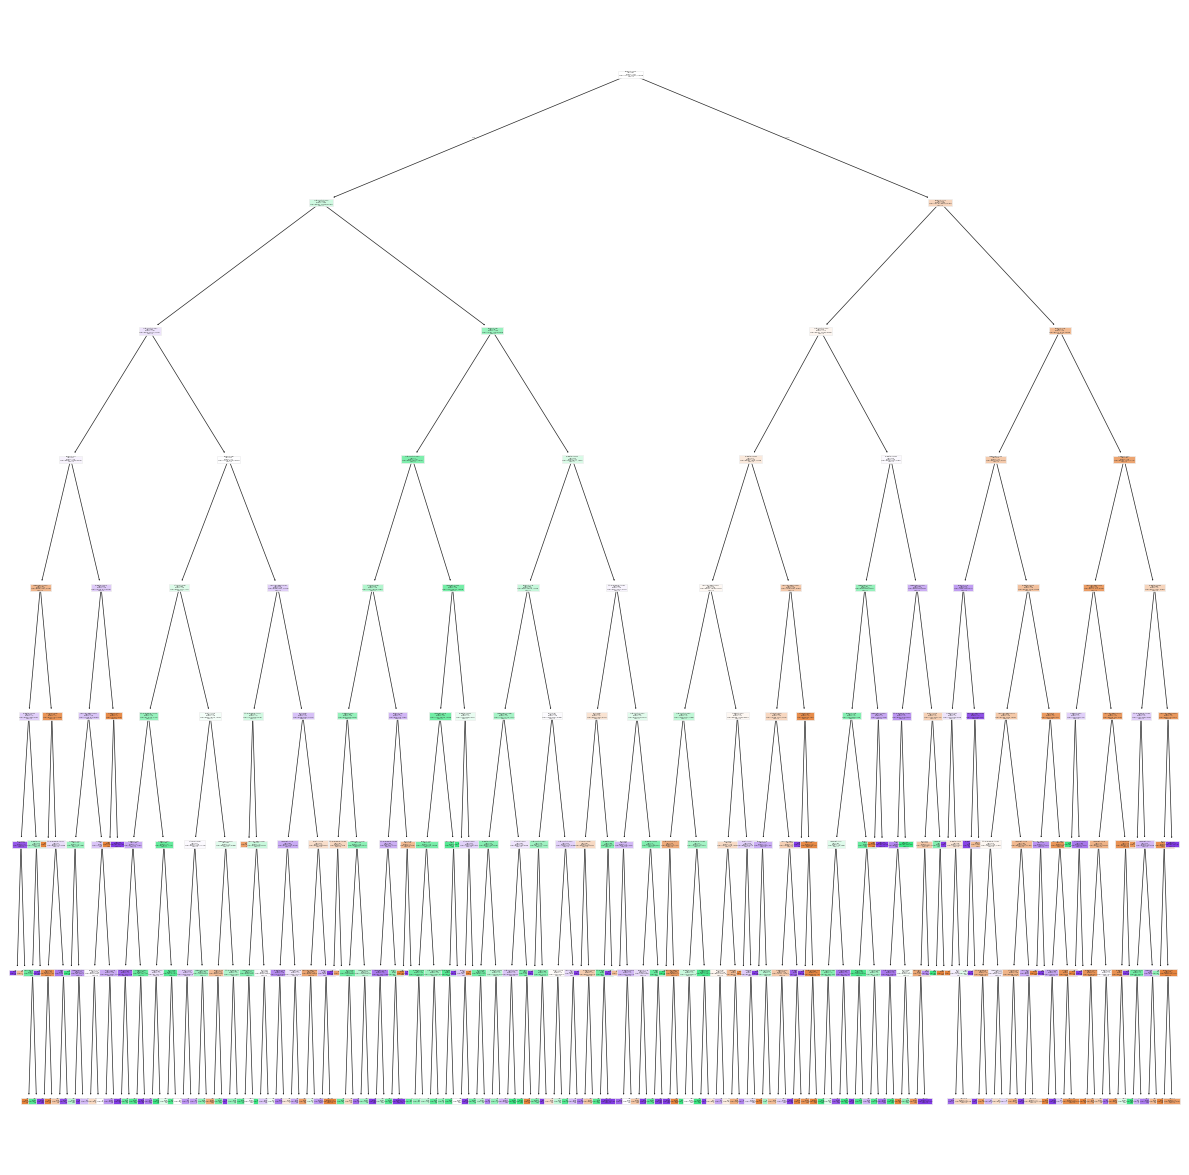

In [288]:
import matplotlib.pyplot as plt
from sklearn import tree

fig = plt.figure(figsize = (15,15))

tree.plot_tree(
    modelo_arbol, 
    feature_names= list(X_train.columns),
    class_names = ['0', '1', '2'],
    filled = True
)

plt.show()

2. Random Forest


=== Métricas Random Forest ===
Accuracy:  0.6862
Precision (macro): 0.6801
Recall (macro):    0.6972
F1-score (macro):  0.6872


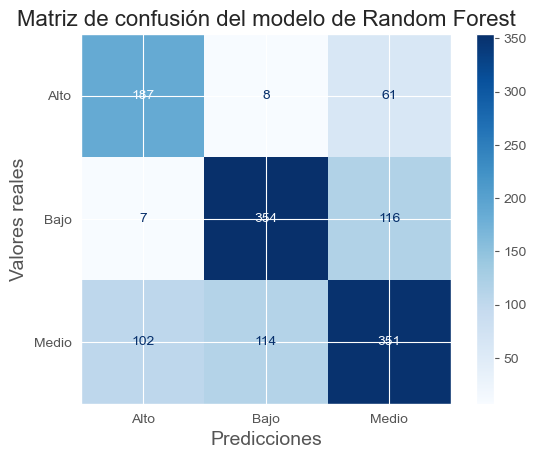

array(['Alto', 'Medio', 'Alto', ..., 'Medio', 'Bajo', 'Bajo'],
      shape=(1300,), dtype=object)

In [289]:
modelo_random = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,        #Limito la profundidad del arbol para evitar el overfitting y mejorar la generalización del modelo. Esto significa que el árbol no se dividirá en nodos adicionales si el número de muestras en un nodo es menor que 5.
    n_jobs=-1,                  #Uso todos los núcleos de la CPU para entrenar el modelo en paralelo, lo que acelera el proceso de entrenamiento.
)

modelo_random.fit(X_train, y_train)
evaluar_modelo('Random Forest', modelo_random, X_test, y_test)

Importancias de Variables (Random Forest)

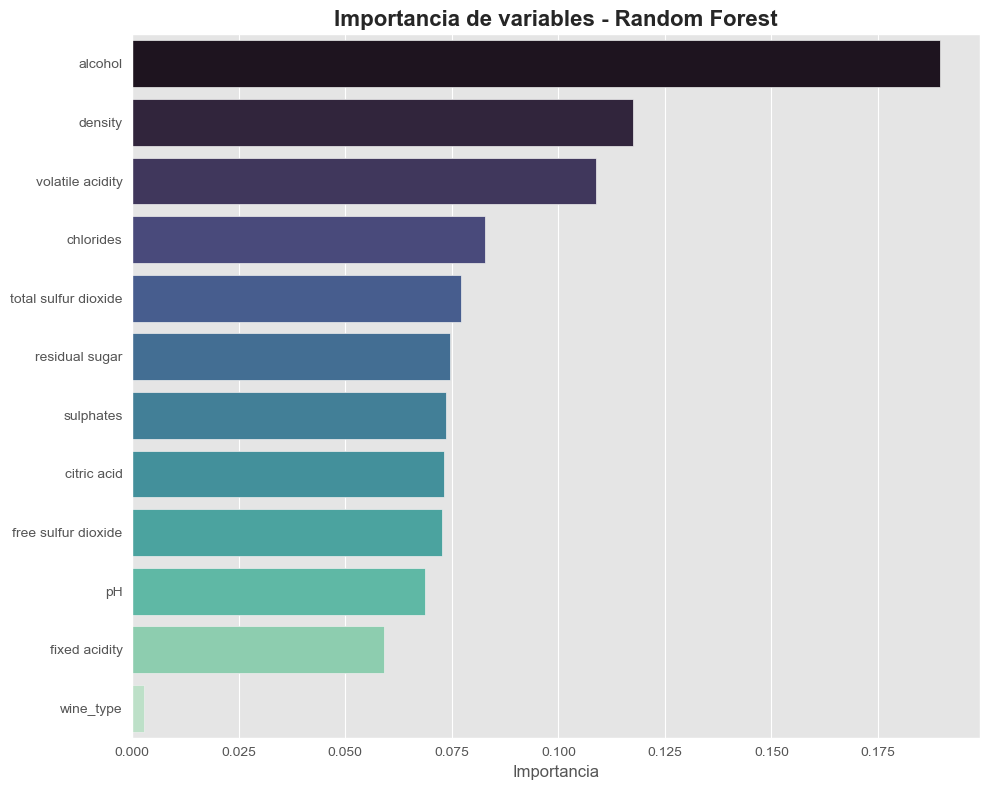


=== Top 10 variables más importantes (Random Forest) ===
alcohol                 0.189455
density                 0.117412
volatile acidity        0.108732
chlorides               0.082783
total sulfur dioxide    0.077128
residual sugar          0.074616
sulphates               0.073542
citric acid             0.073225
free sulfur dioxide     0.072588
pH                      0.068706
dtype: float64


In [290]:
importancias = pd.Series(modelo_random.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)
 
plt.figure(figsize=(10, 8))
sns.barplot(x=importancias.values, y=importancias.index, palette="mako")
plt.title("Importancia de variables - Random Forest", fontsize=16, fontweight='bold')
plt.xlabel("Importancia")
plt.ylabel("")
plt.tight_layout()
plt.savefig("importancia_variables_rf.png", dpi=150, bbox_inches='tight')

plt.show()
 
print("\n=== Top 10 variables más importantes (Random Forest) ===")
print(importancias.head(10))

### OPTIMIZACION DE HIPERPARAMETROS PARA EL MODELO RANDOM FOREST

Los hiperparametros son las perillas del modelo que debo configurar antes de entrenar, y me pregunto: cuantos arboles usar, que tan profundos, que combinacion de perillas es la mejor

1. Importacion de librerias 

In [291]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

2. Espacio de busqueda de hiperparametros 

In [292]:
param_dist = {
    'n_estimators':[200, 300, 400, 500, 600],
    'max_depth':[None, 10, 15, 20, 25, 30],
    'min_samples_split':[2, 5, 10, 15],
    'min_samples_leaf':[1, 2, 3, 5, 8],
    'max_features':['sqrt', 'log2', None],
    'class_weight':['balanced', 'balanced_subsample']
}

- n_estimators: Cuantos arboles tiene el bosque, Mas arboles = generalmente mas estable, pero mas lento de entrenar, Es mejor probar entre 200 y 600

- max_depth: Que tan profundo puede crecer cada arbol, None= sin limite (puede sobreajustar), valores bajos (10-15) = arboles mas simples, menos riesgo de overfitting pero puede que no capture suficiente complejidad

- min_samples_split: Minimo de muestras que debe tener un nodo para poder dividirse mas. valores altos = arboles mas conservados (menos overfitting)

- max_features: Cuantas variables considera el arbol en cada division. 'sqrt'= raiz cuadrada del total de variables(estandar), 'log2'=otra variante, None= usa todas 

- class_weight = Como compensa el desbalance de clases, 'balanced' pondera segun la frecuencia global, 'balanced_subsample' reponderar en cada muestra bootstrap individual


- RandomizedSearchCV = elige combinaciones al azar del espacio y solo prueba n_inter = 40



3. Busqueda aleatoria con validacion cruzada (5 folds)
Scoring = f1_macro, porque es la metrica que nos importa de verdad con clases desbalanceadas (no accuracy)

In [293]:
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier( random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)
print (f"Mejor puntuación F1 (macro) en validación cruzada: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END class_weight=balanced_subsample, max_depth=25, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.8s
[CV] END class_weight=balanced_subsample, max_depth=25, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.8s
[CV] END class_weight=balanced_subsample, max_depth=25, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.9s
[CV] END class_weight=balanced_subsample, max_depth=25, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   2.0s
[CV] END class_weight=balanced_subsample, max_depth=25, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   2.0s
[CV] END class_weight=balanced, max_depth=20, max_features=None, min_samples_leaf=5, min_samples_split=15, n_estimators=200; total time=   2.2s
[CV] END class_weight=balance

4. Evaluar el mejor modelo sobre el test set

In [294]:
mejor_rf = random_search.best_estimator_
y_pred = mejor_rf.predict(X_test)

print("\n=== Métricas Random Forest Optimizado ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-score (macro):  {f1_score(y_test, y_pred, average='macro'):.4f}")

print('\n' + classification_report(y_test, y_pred))



=== Métricas Random Forest Optimizado ===
Accuracy:  0.7346
Precision (macro): 0.7571
Recall (macro):    0.7097
F1-score (macro):  0.7266

              precision    recall  f1-score   support

        Alto       0.80      0.59      0.68       256
        Bajo       0.80      0.75      0.77       477
       Medio       0.67      0.78      0.72       567

    accuracy                           0.73      1300
   macro avg       0.76      0.71      0.73      1300
weighted avg       0.74      0.73      0.73      1300



- Se obtuvo un 73% de accuracy (aciertos)
- Se tuvo una precision en: Alto(75%), Bajo (80%) y Medio (68%)
- Se obtuvo un acierto (Recall) de 65% para Alto, 75% para bajo y 75% para medio
- Se obtiene un promedio de 75% de f1-score 

- El accuracy y el F1 dieron valores muy cercanos, eso indica que el modelo no esta sesgado hacia la clase mayoritaria

Explicacion del punto 3:

- mejor_rf = random_search.best_estimator_  : Esto extrae el modelo ganador de las 40 combinaciones que se probo, 

- y_pred = mejor_rf.predict(X_test)
X_test es el conjunto que nunca se uso no para entrenar ni para la validacion cruzada durante la busqueda de hiperparametros. El modelo jamas lo ha visto, por eso esta prediccion es la mas honesta , en donde llega un vino nuevo y el modelo lo evalua sin haberlo visto antes. 

5. Matriz de confusión del modelo optimizado

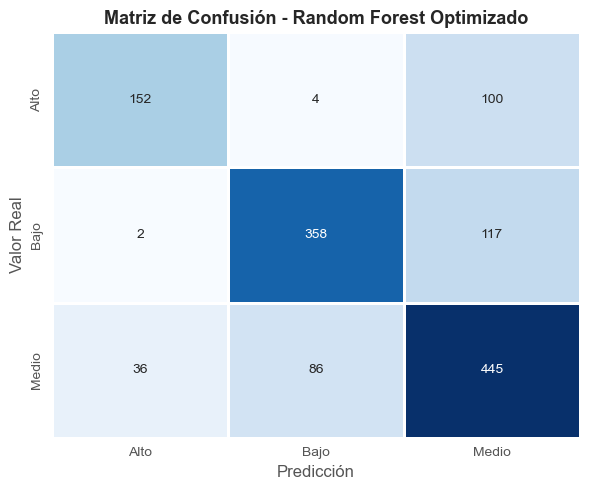

In [295]:
cm = confusion_matrix(y_test, y_pred, labels = clases)

plt.figure(figsize = (6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=clases,
    yticklabels=clases,
    cbar=False,
    linewidths=1,
    linecolor='white',
)

plt.title('Matriz de Confusión - Random Forest Optimizado', fontsize=13, fontweight='bold')

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.savefig('Presentacion_matriz_confusion.png', dpi=200, bbox_inches='tight')

plt.show()

6. Comparación de los valores F1-Score entre el modelo antes y después de optimizarlo

In [296]:
F1_antes =  0.6858
F1_despues = f1_score(y_test, y_pred, average='macro')


comparacion_f1 = pd.DataFrame({
    'Modelo': ['Random Forest sin optimización', 'Random Forest optimizado'],
    'F1-score (macro)': [F1_antes, F1_despues]
})

print (comparacion_f1)
print(comparacion_f1.to_string(index=False))



                           Modelo  F1-score (macro)
0  Random Forest sin optimización          0.685800
1        Random Forest optimizado          0.726611
                        Modelo  F1-score (macro)
Random Forest sin optimización          0.685800
      Random Forest optimizado          0.726611


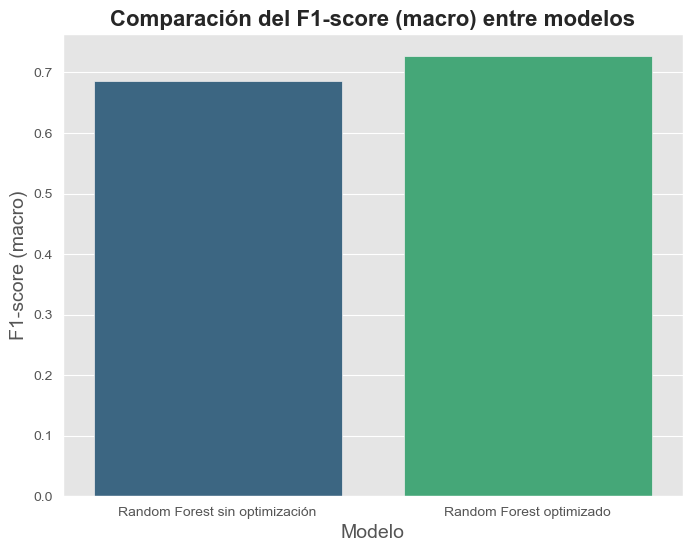

In [297]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Modelo',
    y='F1-score (macro)',
    data=comparacion_f1,
    palette='viridis'
)
plt.title('Comparación del F1-score (macro) entre modelos', fontsize=16, fontweight='bold')
plt.ylabel('F1-score (macro)', fontsize=14)
plt.xlabel('Modelo', fontsize=14)
plt.show()

7. Importancia de variables del modelo final 

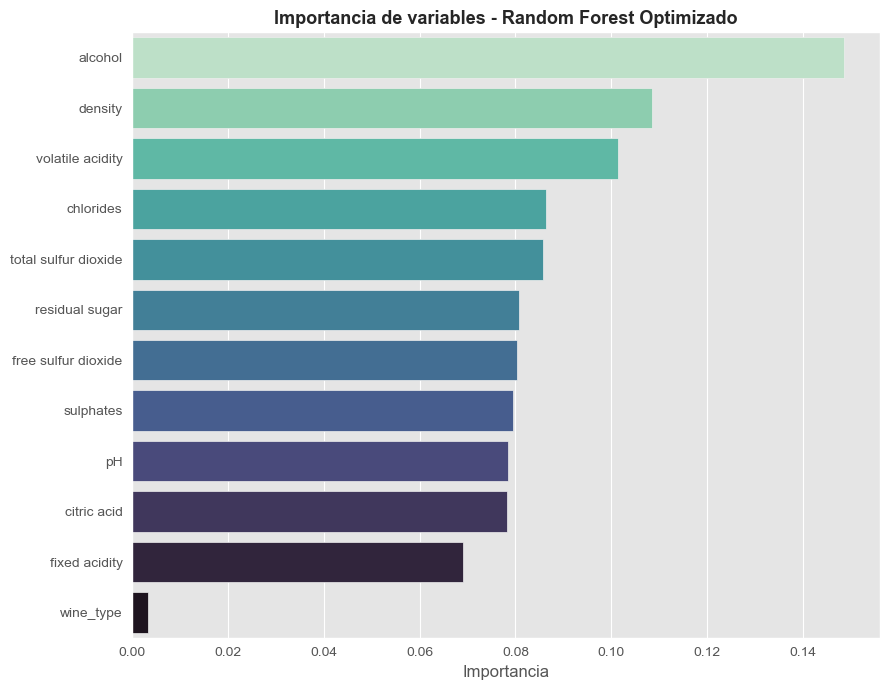


=== Top 10 variables más importantes (Random Forest Optimizado) ===
alcohol                 0.148649
density                 0.108420
volatile acidity        0.101457
chlorides               0.086307
total sulfur dioxide    0.085643
residual sugar          0.080813
free sulfur dioxide     0.080212
sulphates               0.079543
pH                      0.078498
citric acid             0.078250
dtype: float64


In [298]:
importancias = pd.Series(mejor_rf.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(9, 7))
colores = sns.color_palette('mako', len(importancias))[::-1]
sns.barplot(x=importancias.values, y=importancias.index, palette=colores)
plt.title("Importancia de variables - Random Forest Optimizado", fontsize=13, fontweight='bold')
plt.xlabel("Importancia")
plt.ylabel("")
plt.tight_layout()
plt.savefig("importancia_variables_rf_optimizado.png", dpi=200, bbox_inches='tight')

plt.show()

print ('\n=== Top 10 variables más importantes (Random Forest Optimizado) ===')
print(importancias.head(10))

7. Curvas ROC multiclase (One Vs Rest)

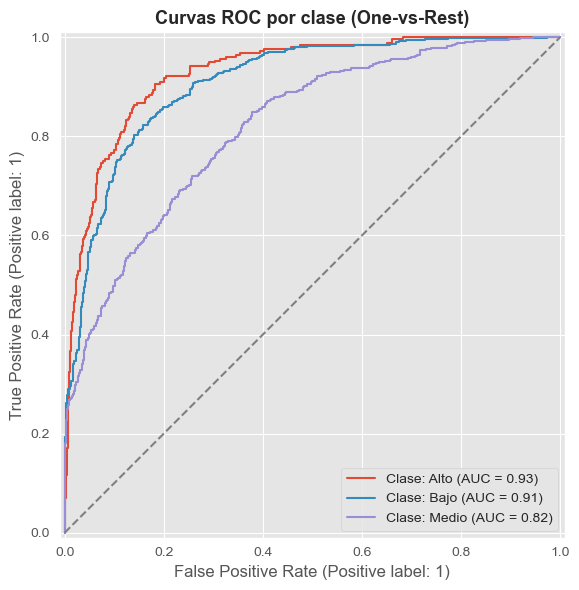

In [299]:
y_test_bin = label_binarize(y_test, classes=clases)
 
fig, ax = plt.subplots(figsize=(7, 6))
for i, clase in enumerate(clases):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i], y_proba[:, i],
        name=f"Clase: {clase}", ax=ax
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curvas ROC por clase (One-vs-Rest)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("presentacion_curvas_roc.png", dpi=200, bbox_inches="tight")
plt.show()

A partir de los AUC (el área bajo la curva) me indican:

- Clase : Alto = 0,93 -> la interpretación del modelo es casi excelente porque puede distinguir muy bien los vinos de alta calidad del resto 

- Clase: Bajo = 0,91 -> La interpreación del modelo también es casi excelente, a pesar de ser la clase con menos datos, el modelo es capaz de distinguir

- Clase: Medio = 0.82 -> La interpretación del modelo es buena, pero es la más debil de las tresn. 


Se puede decir que el modelo precide de manera casi excelente los dos casos más criticos en un control de calidad, la calidad Alta y la calidad Baja, es decir, los dos extremos. Esto se debe a que cuando un vino tiene propiedades fisicoquimicas distinguidas entre sí, estan indicando un comportamiento, ya sea bajo o alto, es decir, es nuestro punto de alerta en caso tal de que un vino sea de mala calidad en proceso de producción. 

### Visualización del Random Forest Optimizado - Limitado a 3 niveles 

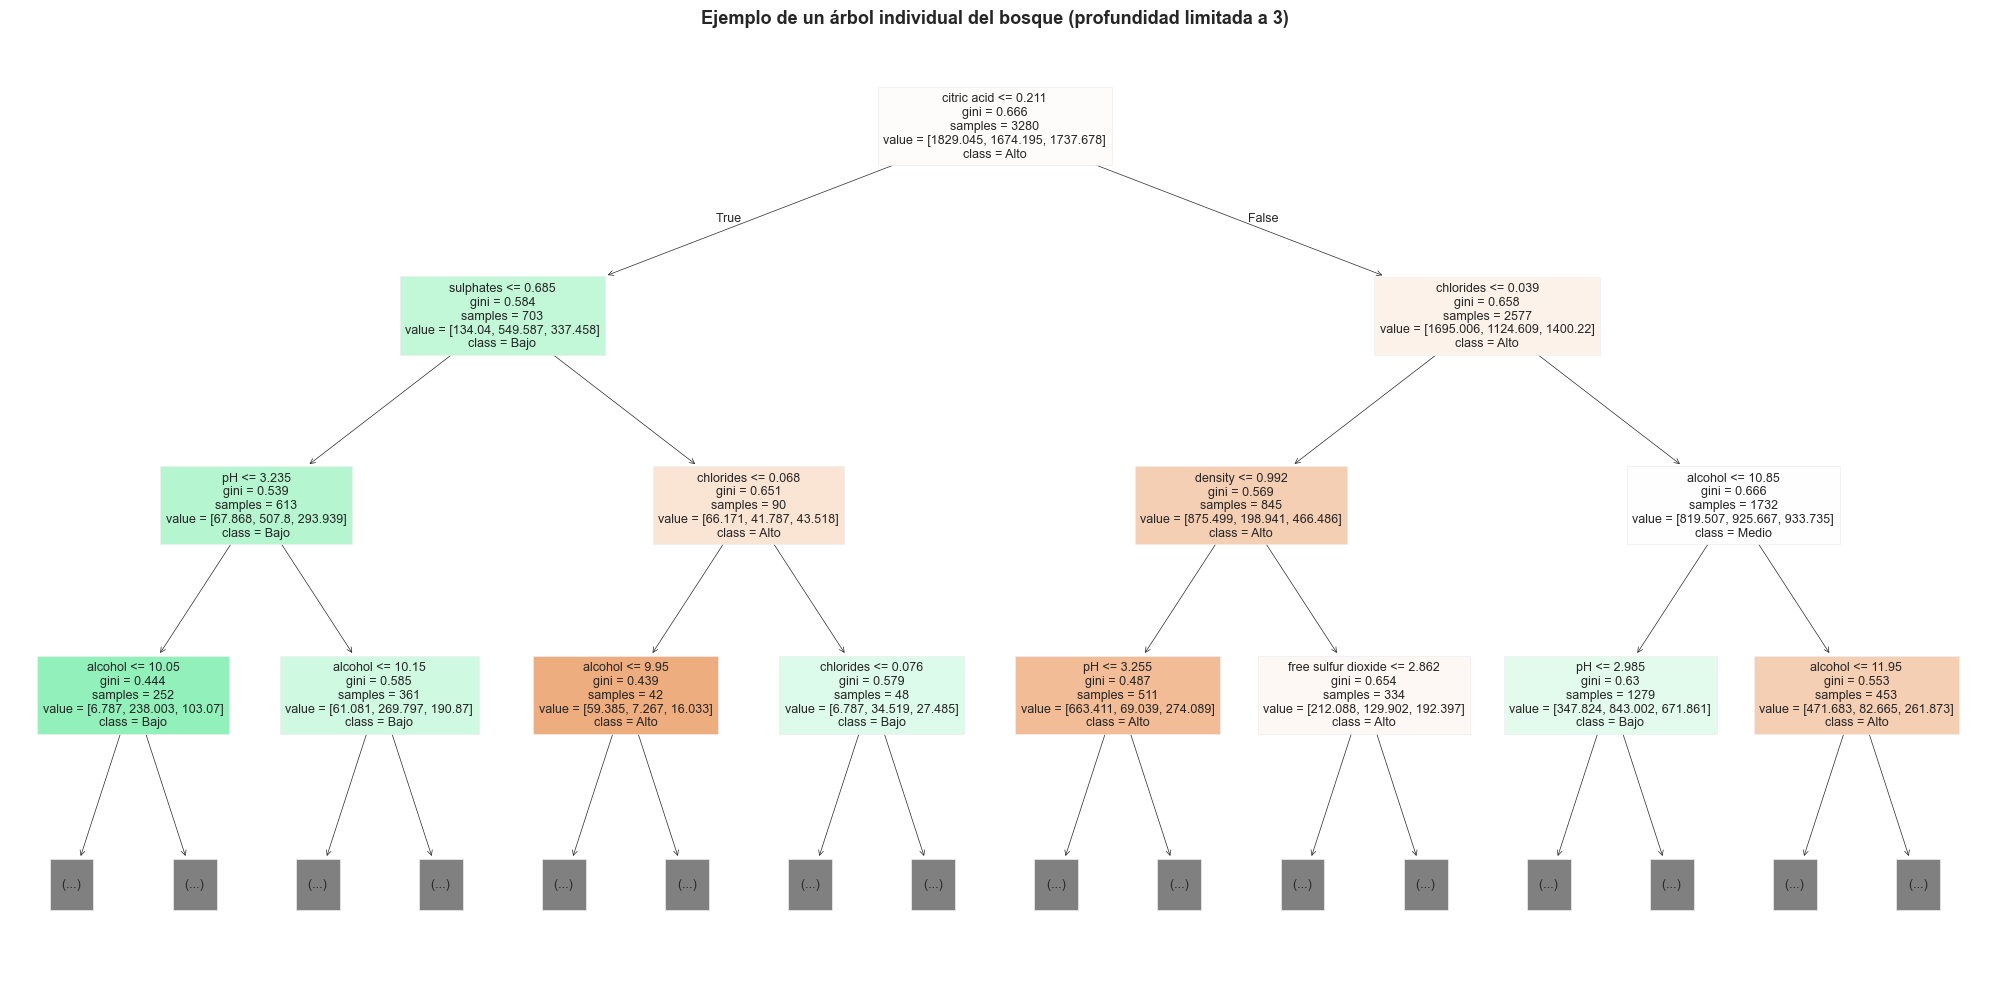

In [300]:
plt.figure(figsize=(20, 10))
plot_tree(
    mejor_rf.estimators_[0],   # el primer árbol del bosque
    feature_names=X_train.columns,
    class_names=[str(c) for c in clases],
    filled=True,
    max_depth=3,               # limitado a 3 niveles para que sea legible
    fontsize=9
)
plt.title("Ejemplo de un árbol individual del bosque (profundidad limitada a 3)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("presentacion_arbol_ejemplo.png", dpi=200, bbox_inches="tight")
plt.show()

El grafico del Randon Forest, nos muestra en el Nodo Raiz que una de las variables decisivas es el acido citrico, y cuando se tiene un acido citrico bajo tiende hacia la izquierda (bajo). 

En el segundo nivel:
En la rama izquierda, la siguiente variable a preguntar son los sulfatos, si estos son bajos, se inclina fuerte hacia 'Bajo'. 
En la rama derecha, después de pasar el control de acido citrico, preguntan por el porcentaje de alcohol, es decir, el alcohol es la segunda variable critica para clasificar el vino.

En el tercer nivel, ya comienza a preguntar por el resto de variables. 

Esto concluye que, el acido citrico y el alcohol son las dos principales variables para clasificar el vino, esto cobra coherencia al nivel quimico, porque cuando se tiene un buen proceso de fermentación, se obtiene un grado de alcohol alto y una acidez estable sin generar sabor u olor avinagrado.


### CONCLUSIONES DEL MODELO RANDOM FOREST

El modelo no asume un linealidad, por ende, es conveniente para evitar lo ocurrido con el modelo de Regresión Logística. 

El resultado confirmó la hipótesis: El Random Forest pasó de un F1 macro cercano a 0 en dos de tres clases, este modelo si distinguió entre las tres categorias con un desempeño razonable y consistente entre ellas. 

### PUNTO 7. DESPLIEGUE DEL MODELO

In [301]:
import joblib

In [302]:
mejor_rf = random_search.best_estimator_
joblib.dump(mejor_rf, 'mejor_modelo_random_forest.pkl')

['mejor_modelo_random_forest.pkl']

In [303]:
columnas_modelo = list (X_train.columns)
joblib.dump(columnas_modelo, 'columnas_modelo.pkl')

['columnas_modelo.pkl']

In [304]:
print ('Modelo y Columnas guardados correctamente')
print (f'El modelo espera {len(columnas_modelo)} columnas:')
print (columnas_modelo)

Modelo y Columnas guardados correctamente
El modelo espera 12 columnas:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type']


### App Streamlit - Predicción de Calidad de Vino

Ejecutar con: streamllit run app.py

In [305]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

Configuración de la página

In [306]:
st.set_page_config(
    page_title = 'Predictor de Calidad de Vino',
    page_icon = '🍷',
    layout = 'centered'
)

2026-07-26 18:23:00.238 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Cargar modelo y columnas (lo haré con caché para no recargar en cada iterección del usuario)

In [307]:
@st.cache_resource

def cargar_modelo():
    modelo = joblib.load('modelo_wine_quality.pkl')
    columnas = joblib.load('columnass_modelo.pkl')
    return modelo, columnas
    modelo, columnas_modelo = cargar_modelo()

El encabezado de la App

In [308]:
st.title('Predictor de Calidad de Vino')
st.markdown(
    ' Ingresar las propiedades fisicoquímicas del vino y el modelo'
    'Predicirá su categoría de calidad: **Bajo**, **Medio** o **Alto**.'
)

st.divider()

2026-07-26 18:23:00.250 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.251 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.251 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.251 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.252 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.252 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.253 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.253 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

El formulario de entrada

In [309]:
st.subheader ('Tipo de vino')
tipo_vino = st.selectbox('Tipo de vino', ['Red', 'White'])

st.subheader('Propiedades fisicoquímicas')

col1, col2 = st.columns(2)

with col1:

    fixed_acidity = st.slider ('Acidez fija (g/L)', 3.8, 15.9, 7.2, 0.1)
    volatile_acidity = st.slider("Acidez volátil (g/L)", 0.08, 1.58, 0.34, 0.01)
    citric_acid = st.slider("Ácido cítrico (g/L)", 0.0, 1.66, 0.32, 0.01)
    residual_sugar = st.slider("Azúcar residual (g/L)", 0.6, 65.8, 5.4, 0.1)
    chlorides = st.slider("Cloruros (g/L)", 0.009, 0.611, 0.056, 0.001)
    free_sulfur_dioxide = st.slider("Dióxido de azufre libre (mg/L)", 1, 289, 30)
 
with col2:
    total_sulfur_dioxide = st.slider("Dióxido de azufre total (mg/L)", 6, 440, 115)
    density = st.slider("Densidad (g/cm³)", 0.987, 1.039, 0.995, 0.0001, format="%.4f")
    pH = st.slider("pH", 2.72, 4.01, 3.22, 0.01)
    sulphates = st.slider("Sulfatos (g/L)", 0.22, 2.0, 0.53, 0.01)
    alcohol = st.slider("Alcohol (% vol.)", 8.0, 14.9, 10.5, 0.1)

st.divider()
 

2026-07-26 18:23:00.261 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.261 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.262 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.262 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.262 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.262 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.263 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.263 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

El botón de predicción, armo un diccionario con las variables originales, el modelo fue entrenado con 5 valiables transformadas con log1p, asi que replico lo mismo 

In [310]:
if st.button ("🔍 Predecir calidad", type="primary", use_container_width=True) :
  datos = {
    "fixed acidity": fixed_acidity,
    "volatile acidity": volatile_acidity,
    "citric acid": np.log1p(citric_acid),
    "residual sugar": np.log1p(residual_sugar),      # transformada
    "chlorides": np.log1p(chlorides),                 # transformada
    "free sulfur dioxide": np.log1p(free_sulfur_dioxide),   # transformada
    "total sulfur dioxide": np.log1p(total_sulfur_dioxide), # transformada
    "density": density,
    "pH": pH,
    "sulphates": sulphates,
    "alcohol": alcohol,
    'wine_type': 0 if tipo_vino == 'Red' else 1,
  }
  #Convierto el DataFrame con el orden exacto de las columnas que el modelo espera
  wine_data = pd.DataFrame([datos])
  wine_data = wine_data[columnas_modelo]

  #Predicción
  prediccion = modelo.predict (wine_data)[0]
  probabilidades = modelo.predict_proba(wine_data)[0]

  #Mostrar los resultados 
  colores = {"bajo": "🔴", "medio": "🟡", "alto": "🟢"}
  st.subheader(f"Resultado: {colores.get(prediccion, '')} Calidad **{prediccion.upper()}**")

  prob_wine_data = pd.DataFrame({
    'Categoría': modelo.classes_,
    'Probabilidad': probabilidades
    }).sort_values('Probabilidad', ascending = False)

  st.bar_chart(prob_wine_data.set_index('Categoría'))

st.divider()
st.caption(
  'Modelo: Random Forest Optimizado | Dataset: Wine Quality (UCI) | '
  'Proyecto de Machine Learning'
)

2026-07-26 18:23:00.291 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.295 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.297 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 18:23:00.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [311]:
joblib.dump(mejor_rf, 'mejor_modelo_random_forest.pkl', compress=3)

['mejor_modelo_random_forest.pkl']